In [1]:
# Cell 1 - Import libraries needed for data handling and visualization

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# Cell 2 - Load SQL-cleaned merged dataset and inspect shape, structure, nulls, duplicates

df = pd.read_csv('../data/processed/train_store_merged.csv', parse_dates=['Date'])

print('\nRows and Columns in dataset:')
print('-' * 50)
print(df.shape)

print('\nSummary:')
print('-' * 50)
df.info()

print("\nNull values per row:")
print('-' * 50)
print(df.isnull().sum())

print("\nDuplicate rows:")
print('-' * 50)
print(df.duplicated().sum())


Rows and Columns in dataset:
--------------------------------------------------
(1017209, 18)

Summary:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType             

In [3]:
# Cell 3 - Fill missing CompetitionDistance with median (outlier-resistant, unlike mean)

df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
print(df['CompetitionDistance'].isnull().sum())

0


In [4]:
# Cell 4 - Leave "not applicable" nulls as NaN (CompetitionOpenSince*, Promo2Since*)
# Label PromoInterval nulls explicitly since it's a text/category column

print('Null Values:')
print(df[['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
    'Promo2SinceWeek', 'Promo2SinceYear']].isnull().sum())

df['PromoInterval'] = df['PromoInterval'].fillna('No Promo2')

Null Values:
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2SinceWeek              508031
Promo2SinceYear              508031
dtype: int64


In [5]:
# Cell 5 - Remove closed-store and zero-sale rows; they reflect no operation,
# not zero demand, and would distort every downstream average

df = df[(df['Open'] == 1) & (df['Sales'] > 0)]
df.shape

(844338, 18)

In [6]:
# Cell 6 - Feature engineering: break Date into Month, Year, WeekOfYear

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

In [7]:
# Cell 7 - Save cleaned, feature-engineered dataset

df.to_csv('../data/processed/rossmann_cleaned.csv', index=False)

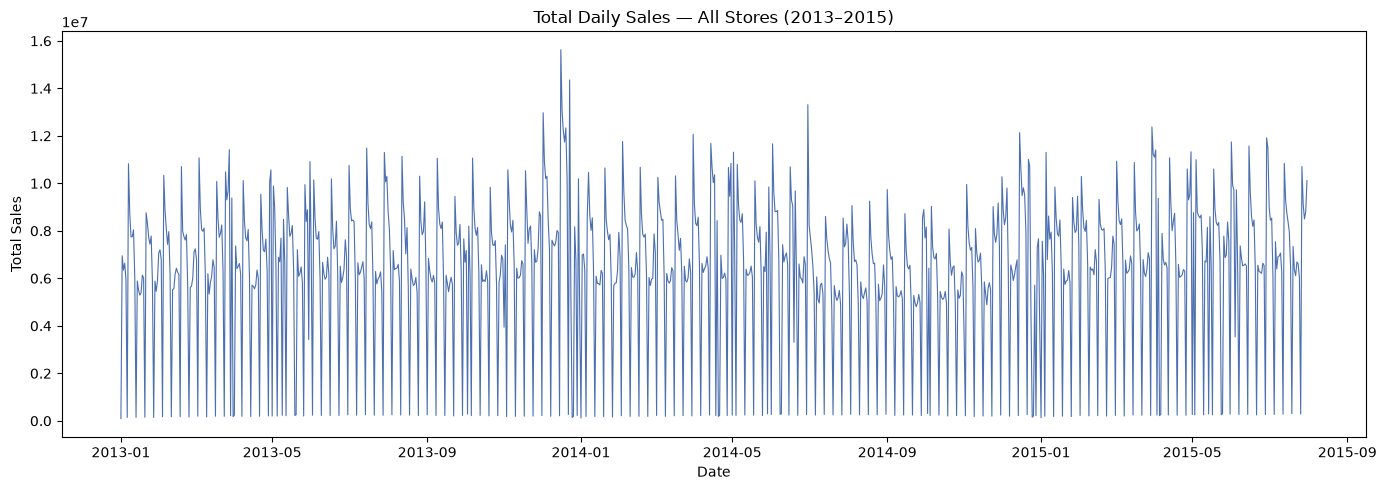

In [12]:
# Cell 8 - Line chart of total daily sales across the full dataset, to
# visually confirm trend/seasonality patterns before any modeling

daily_sales = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales.index, daily_sales.values, linewidth=0.8, color="#4C6FB0")
plt.title('Total Daily Sales — All Stores (2013–2015)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()

plt.savefig('../outputs/charts/08_daily_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

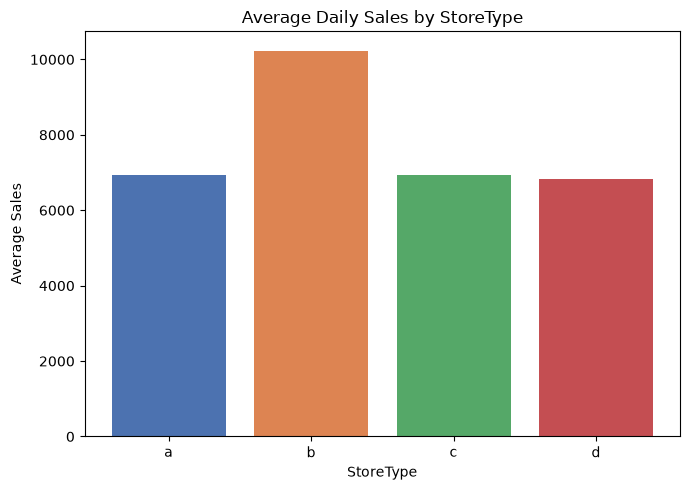

In [9]:
# Cell 9 - Bar chart of average daily sales by StoreType

storetype_avg = df.groupby('StoreType')['Sales'].mean().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(storetype_avg.index, storetype_avg.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('Average Daily Sales by StoreType')
plt.xlabel('StoreType')
plt.ylabel('Average Sales')
plt.tight_layout()

plt.savefig('../outputs/charts/09_avg_sales_by_storetype.png', dpi=150, bbox_inches='tight')
plt.show()

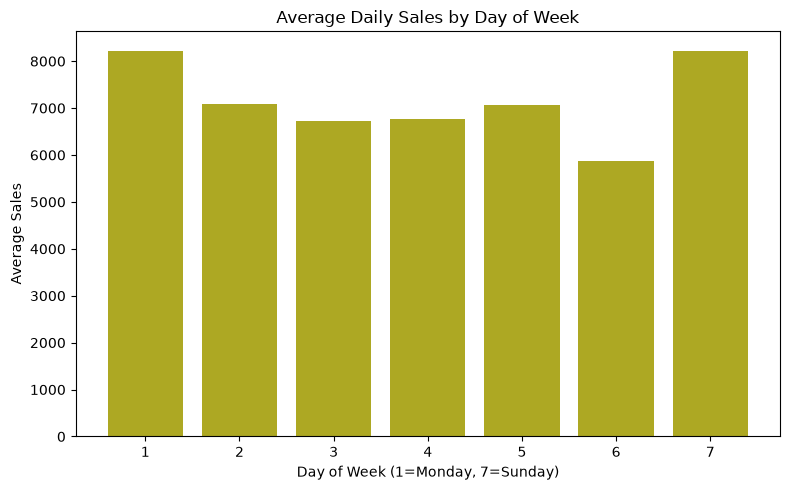

In [14]:
# Cell 10 - Bar chart of average daily sales by DayOfWeek

dow_avg = df.groupby('DayOfWeek')['Sales'].mean().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(dow_avg.index, dow_avg.values, color="#ADA823")
plt.title('Average Daily Sales by Day of Week')
plt.xlabel('Day of Week (1=Monday, 7=Sunday)')
plt.ylabel('Average Sales')
plt.xticks(range(1, 8))
plt.tight_layout()

plt.savefig('../outputs/charts/10_avg_sales_by_dayofweek.png', dpi=150, bbox_inches='tight')
plt.show()

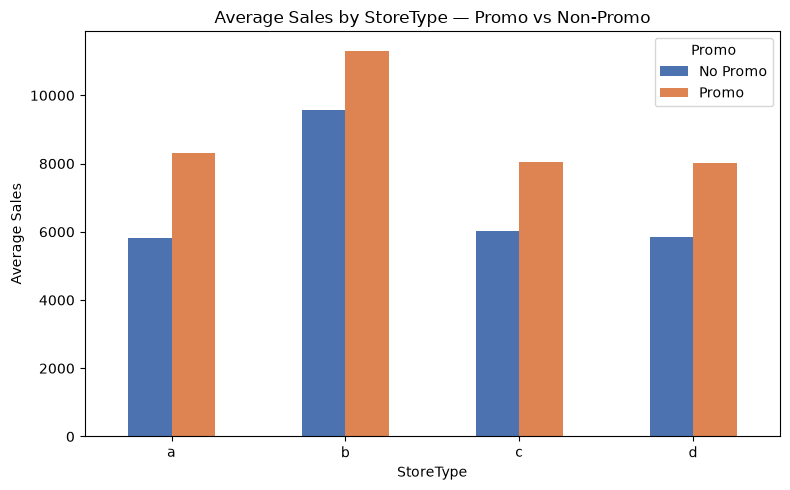

In [15]:
# Cell 11 - Grouped bar chart: average sales by StoreType, split by Promo,
# to visually confirm the promo lift 

promo_by_type = df.groupby(['StoreType', 'Promo'])['Sales'].mean().unstack()

promo_by_type.plot(kind='bar', figsize=(8, 5), color=['#4C72B0', '#DD8452'])
plt.title('Average Sales by StoreType — Promo vs Non-Promo')
plt.xlabel('StoreType')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.legend(title='Promo', labels=['No Promo', 'Promo'])
plt.tight_layout()

plt.savefig('../outputs/charts/11_promo_by_storetype.png', dpi=150, bbox_inches='tight')
plt.show()

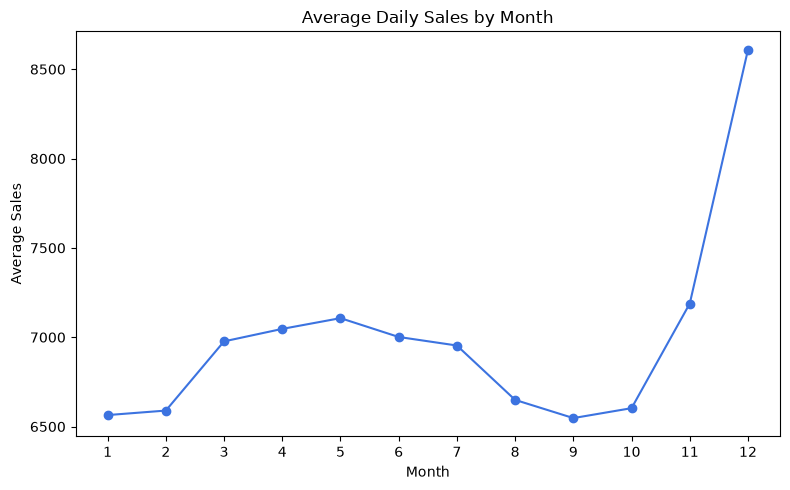

In [17]:
# Cell 12 - Line chart, average sales by calendar month (collapsed across all years)

month_sales = df.groupby('Month')['Sales'].mean()

plt.figure(figsize=(8, 5))
plt.plot(month_sales.index, month_sales.values, color="#3C73E0", linewidth=1.5, marker='o')
plt.title('Average Daily Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1, 13))
plt.tight_layout()

plt.savefig('../outputs/charts/12_avg_sales_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

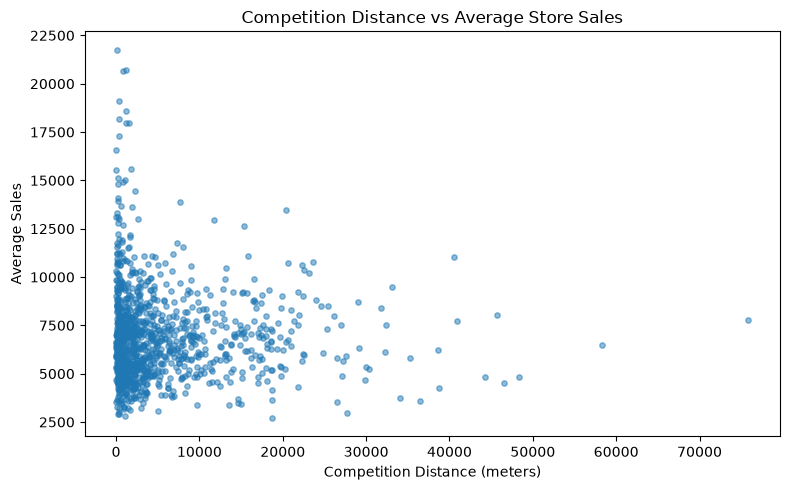

In [18]:
# Cell 13 - Scatter plot: CompetitionDistance vs average store sales, to check
# whether nearby competition measurably affects a store's typical sales

store_summary = df.groupby('Store').agg({
    'Sales': 'mean',
    'CompetitionDistance': 'first'
})

plt.figure(figsize=(8, 5))
plt.scatter(store_summary['CompetitionDistance'], store_summary['Sales'], alpha=0.5, s=15)
plt.title('Competition Distance vs Average Store Sales')
plt.xlabel('Competition Distance (meters)')
plt.ylabel('Average Sales')
plt.tight_layout()

plt.savefig('../outputs/charts/13_competition_distance_vs_sales.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Insights

1. **December sales spike sharply, then correct in January.** Average sales 
   jump ~17–18% in December compared to November, confirmed independently 
   across Excel, SQL, and this notebook — then drop by a similar magnitude 
   in January. This is the strongest, most consistently repeated pattern 
   found in the dataset.

2. **StoreType B consistently outperforms, and it's structurally different, 
   not just lucky.** It shows the highest average daily sales of all four 
   store formats (confirmed in Excel, SQL, and here), is the rarest 
   StoreType by count, is the only format carrying Assortment B, and stays 
   open more consistently than the others — four distinct facts pointing 
   to the same small, atypical group.

3. **Promotions increase sales at every store, with wide variation in how 
   much.** Every store analyzed showed a positive promo lift (SQL Query 3), 
   confirmed again at the StoreType level here — but the size of that lift 
   ranged from under 20% to over 80% across stores, meaning promo 
   effectiveness isn't uniform and may depend on other store characteristics.

4. **Sunday sales are lower even among stores that remain open.** After 
   removing closed-store days entirely, Sunday still shows the lowest 
   average sales of any day — suggesting reduced Sunday demand isn't fully 
   explained by store closures alone.

5. **Distance from a competitor doesn't guarantee higher sales, but 
   extreme distance appears to cap it.** Stores far from any competitor 
   never reach the top sales tier, while stores close to competitors show 
   both very high and very low performance — a pattern more consistent 
   with dense, high-traffic locations having more competition *and* more 
   customers, rather than competition directly hurting sales.